Mp2 results

In [1]:
import pandas as pd
from mandelprot_lecture_4 import benchmark_mandelbrot_all

xmin, xmax = -2.0, 1.0
ymin, ymax = -1.5, 1.5
width, height = 2000, 1500
max_iter = 500
chunk_rows = 64

baseline, rows = benchmark_mandelbrot_all(
    xmin,
    xmax,
    ymin,
    ymax,
    width,
    height,
    max_iter,
    chunk_rows=chunk_rows,
    process_counts=[1, 2, 4, 8],
    runs=5,
)

df = pd.DataFrame(rows)
print("Sequential baseline:", baseline)
df

Sequential baseline: 0.5809248000005027


,processes,median_time_s,min_time_s,max_time_s,speedup,efficiency
0,1,1.595411,1.552589,1.718707,0.364122,0.364122
1,2,1.245239,1.228895,1.251493,0.466517,0.233258
2,4,1.151602,1.134283,1.183512,0.504449,0.126112
3,8,1.332930,1.291599,1.346648,0.435825,0.054478


The results show that the parallel implementation was slower than the , since the speedup remained below 1.0 in every case.

A explanation could be that the sequential version was already highly optimized by Numba, so the remaining work was not large enough to offset the overhead introduced by multiprocessing.

This is consistent with the general idea behind Amdahl’s Law, where the achievable benefit from parallelism is limited by serial work and parallel overhead.

Lecture 5 results

M1 same image: True
M1 chunks = 4 time: 0.5033 s
M1 chunks = 16 time: 0.3669 s
M2 best chunk row: {'n_chunks': 64, 'time_s': 0.34767759998794645, 'min_s': 0.3470439999946393, 'max_s': 0.348552599985851, 't1_s': 1.2607582000200637, 'speedup': 3.6262278618575734, 'LIF': 0.10307464185412729}
Estimated serial fraction s: 0.026592
Tracker (1024x1024) median: 0.1287 s


,n_chunks,time_s,min_s,max_s,t1_s,speedup,LIF
0,4,0.639424,0.624884,0.645411,1.261779,1.973306,1.027055
1,8,0.285224,0.278602,0.319695,0.750783,2.632257,0.519608
2,16,0.289590,0.282720,0.294402,0.682001,2.355054,0.698475
3,32,0.371663,0.360085,0.408196,1.080374,2.906866,0.376052
4,64,0.347678,0.347044,0.348553,1.260758,3.626228,0.103075


,processes,n_chunks,time_s,min_s,max_s,speedup,ideal_speedup
0,1,64,0.662159,0.650215,0.923150,1.663852,1.0
1,2,64,0.363049,0.360242,0.367534,3.034668,2.0
2,4,64,0.226197,0.206552,0.246935,4.870673,4.0
3,8,64,0.163352,0.158325,0.164063,6.744544,8.0


,method,time_s,speedup_vs_naive
0,Naive Python,1.631844,1.000000
1,NumPy,0.691248,2.360723
2,Numba,0.048077,33.942583
3,Parallel (optimized),0.019403,84.101364


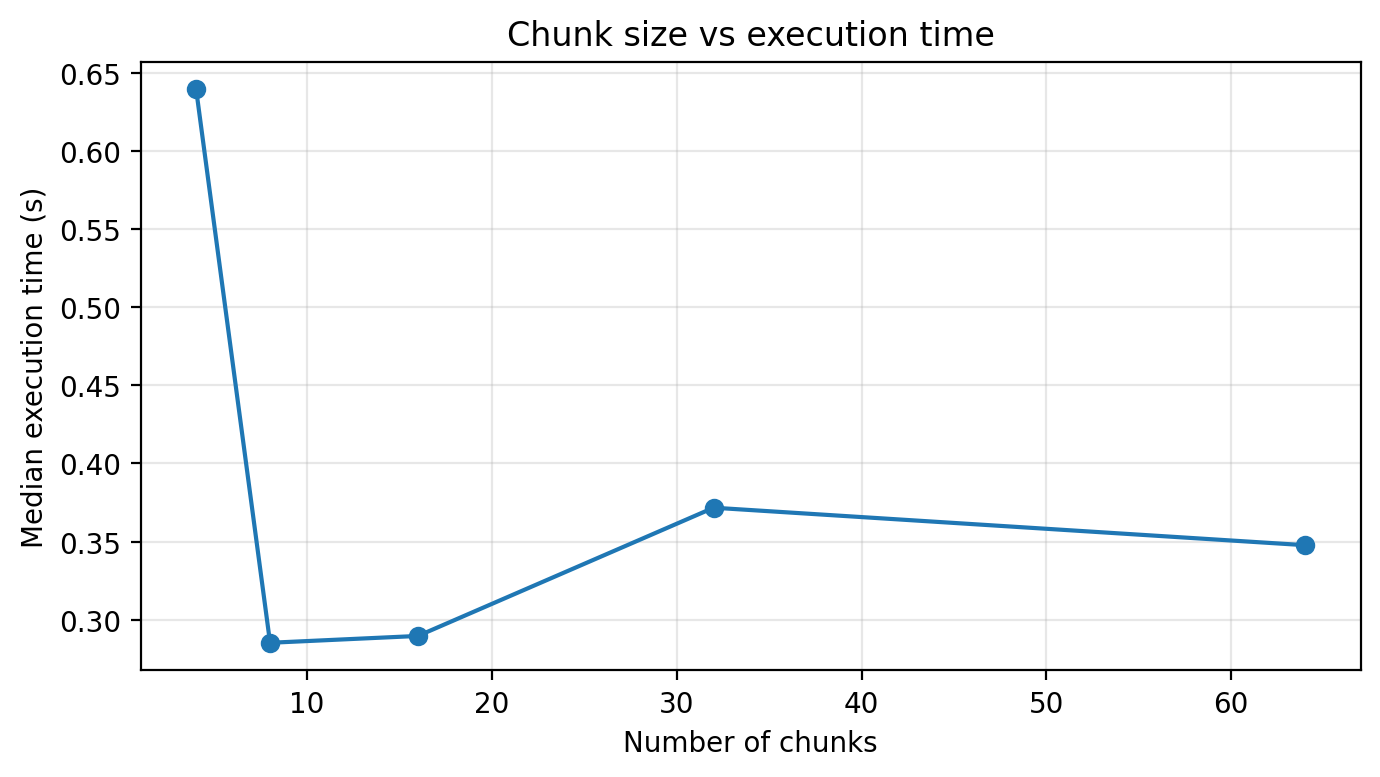

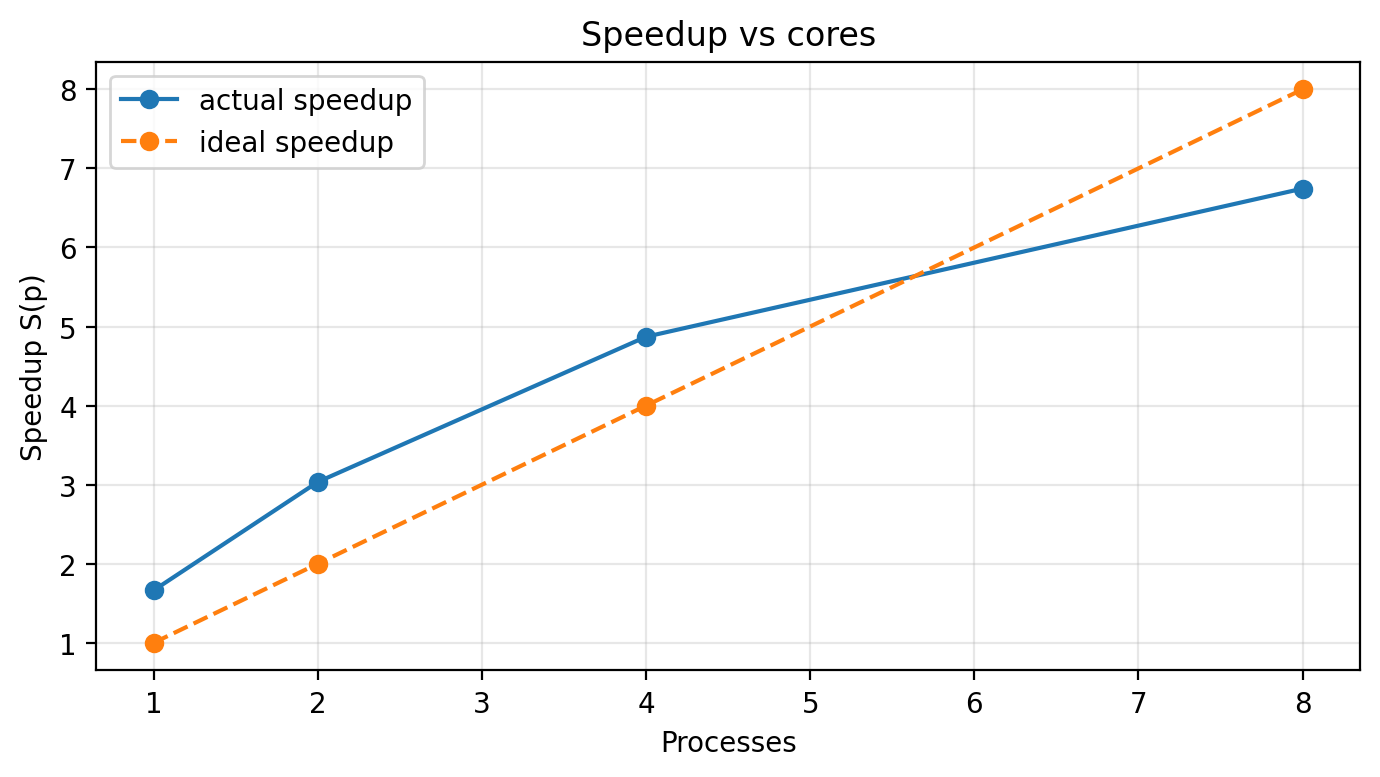

In [1]:
from IPython.display import Image, display
from mandelprot_lecture_5 import (
    plot_chunk_time,
    plot_speedup,
    run_lecture5_study,
    to_dataframes,
)

results = run_lecture5_study(
    width=2000,
    height=1500,
    max_iter=500,
    n_workers_l04=4,
    process_counts=(1, 2, 4, 8),
    runs=3,
)

chunk_df, speed_df, compare_df = to_dataframes(results)

print("M1 same image:", results["m1_same_image"])
print("M1 chunks =", results["m1_chunks_default"], "time:", round(results["m1_time_default"], 4), "s")
print("M1 chunks =", results["m1_chunks_4x"], "time:", round(results["m1_time_4x"], 4), "s")
print("M2 best chunk row:", results["best_chunk_row"])
print("Estimated serial fraction s:", round(results["serial_fraction"], 6))
print("Tracker (1024x1024) median:", round(results["tracker_1024"]["median_s"], 4), "s")

display(chunk_df)
display(speed_df)
display(compare_df)

chunk_plot_path = plot_chunk_time(results["chunk_rows"], "lecture5_chunk_time.png")
speed_plot_path = plot_speedup(results["speed_rows"], "lecture5_speedup.png")

display(Image(filename=chunk_plot_path))
display(Image(filename=speed_plot_path))


In [2]:
# Short interpretation generated from current run
best_speed_row = max(results["speed_rows"], key=lambda r: r["speedup"])
best_chunk_row = results["best_chunk_row"]

print("Interpretation")
print("- Fastest chunk setup:", best_chunk_row["n_chunks"], "chunks (LIF =", round(best_chunk_row["LIF"], 4), ")")
print("- Best speedup point:", best_speed_row["processes"], "processes with S(p)=", round(best_speed_row["speedup"], 4))
print("- Multiprocessing worth it here:", best_speed_row["speedup"] > 1.0)
print("- Why chunking helps: equal chunk sizes can still have unequal work in Mandelbrot rows.")
print("- Granularity tradeoff: too few chunks => load imbalance, too many => overhead.")
print("- Mandelbrot is embarrassingly parallel because pixels/chunks are independent.")


Interpretation
- Fastest chunk setup: 64 chunks (LIF = 0.1031 )
- Best speedup point: 8 processes with S(p)= 6.7445
- Multiprocessing worth it here: True
- Why chunking helps: equal chunk sizes can still have unequal work in Mandelbrot rows.
- Granularity tradeoff: too few chunks => load imbalance, too many => overhead.
- Mandelbrot is embarrassingly parallel because pixels/chunks are independent.


Lecture 6 results

In [ ]:
from IPython.display import Image, display
from mandelprot_lecture_6 import (
    plot_dask_chunk_performance,
    run_lecture6_study,
    to_dataframes,
)

results6 = run_lecture6_study(
    width=400,
    height=300,
    max_iter=120,
    n_workers=4,
    runs=1,
    comparison_width=256,
    comparison_height=256,
    comparison_max_iter=120,
    comparison_runs=1,
)

chunk6_df, compare6_df, tracker6_df = to_dataframes(results6)

print("M1 same image:", results6["m1"]["same_image"])
print("M1 serial time:", round(results6["m1"]["serial_time_s"], 4), "s")
print("M1 Dask time:", round(results6["m1"]["dask_time_s"], 4), "s")
print("M1 speedup vs serial:", round(results6["m1"]["speedup_vs_serial"], 4))
print("M2 best chunk row:", results6["best_chunk_time_row"])
print("M2 best LIF row:", results6["best_chunk_lif_row"])
print("M3 Dask/MP ratio:", round(results6["overhead_vs_multiprocessing"]["dask_vs_mp_ratio"], 4))
print("Tracker path:", results6["tracker_path"])

display(chunk6_df)
display(compare6_df)
display(tracker6_df)

chunk6_plot_path = plot_dask_chunk_performance(
    results6["chunk_rows"],
    "lecture6_dask_chunks.png",
)
display(Image(filename=chunk6_plot_path))


Run summary on March 25, 2026 (compact benchmark config):

- M1 correctness: `same_image=True`
- M1 timing: serial `0.0178s`, Dask `0.0861s`, speedup `0.2068x`
- M2 best chunk row: `n_chunks=4`, time `0.0372s`, speedup `1.6853x`, `LIF=1.3734`
- M3 times (s): Naive `0.5280`, NumPy `0.0885`, Numba `0.0097`, MP `0.0109`, Dask `0.0332`
- Overhead vs multiprocessing: Dask is `3.0335x` slower than MP in this run


In [ ]:
# Short interpretation generated from current run
best_chunk_row6 = results6["best_chunk_time_row"]
overhead6 = results6["overhead_vs_multiprocessing"]

print("Interpretation")
print("- Dask delayed graph is correct vs serial:", results6["m1"]["same_image"])
print("- Best chunk count:", best_chunk_row6["n_chunks"])
print("- Best chunk LIF:", round(best_chunk_row6["LIF"], 4))
print("- MP time:", round(overhead6["mp_time_s"], 4), "s")
print("- Dask time:", round(overhead6["dask_time_s"], 4), "s")
print("- Dask/MP ratio:", round(overhead6["dask_vs_mp_ratio"], 4))
print("- Reflection: Dask adds scheduling overhead, while multiprocessing is lean for this chunked workload.")
